In [7]:
!pip install svgling

import nltk
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

The clever programmer is coding in Python.
(S
  (NP The/DT clever/NN programmer/NN)
  (VP is/VBZ coding/VBG)
  (PP in/IN (NP Python/NNP))
  ./.)


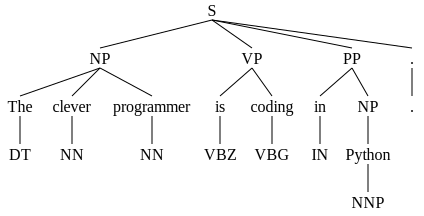

*************************************************************************** 


The car will quickly start.
(S (NP The/DT car/NN) will/MD quickly/RB (VP start/VB) ./.)


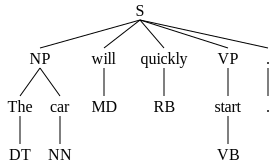

*************************************************************************** 


They should have committed the code.
(S
  They/PRP
  (VP should/MD have/VB committed/VBN)
  (NP the/DT code/NN)
  ./.)


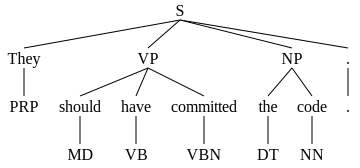

*************************************************************************** 


The data analyst found a critical trend in the massive dataset.
(S
  (NP The/DT data/NNS analyst/NN)
  (VP found/VBD)
  (NP a/DT critical/JJ trend/NN)
  (PP in/IN (NP the/DT massive/JJ dataset/NN))
  ./.)


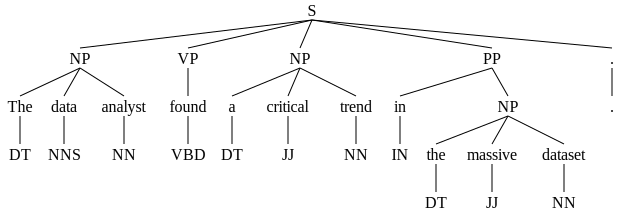

*************************************************************************** 




In [9]:
from nltk import word_tokenize, pos_tag
from nltk.chunk import RegexpParser
from IPython.display import display
import svgling

texts = [
    'The clever programmer is coding in Python.',
    'The car will quickly start.',
    'They should have committed the code.',
    'The data analyst found a critical trend in the massive dataset.'
]

# Define a master grammar combining NP, VP, and PP
grammar = """
    NP:   {<DT>?<JJ>*<NN.*>+}       # Chunk determiners, adjectives, and nouns (Noun Phrase)
    VP:   {<MD>?<VB.*>+<RB.*>*}     # Chunk auxiliary and main verbs (Verb Phrase)
    PP:   {<IN><NP>}                # Chunk prepositions followed by an NP (Prepositional Phrase)
"""

chunk_parser = RegexpParser(grammar)

for text in texts:
  tokens = word_tokenize(text)
  pos_tags = pos_tag(tokens)

  tree = chunk_parser.parse(pos_tags)

  # Display the resulting tree
  print(f'{text}')
  print(tree)
  tree_graphic = svgling.draw_tree(tree)
  display(tree_graphic)
  print('*' * 75,"\n\n")